# Load Dataset

In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, LSTM, Bidirectional, Concatenate, Dropout, Flatten, Lambda, GlobalMaxPooling1D, GlobalAveragePooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.utils import plot_model
from tensorflow.keras.layers import Embedding


In [ ]:
import tensorflow as tf
print(tf.__version__)


2.18.0


In [ ]:
from transformers import BertTokenizer, TFBertModel

In [ ]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# file path in Google Drive
file_path = '/content/drive/MyDrive/bug_reports.csv'

try:
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)

    # Print the first few rows of the DataFrame to verify
    print(df.head())

except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
except pd.errors.ParserError:
    print(f"Error: Could not parse the CSV file at {file_path}. Check the file format.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Bug Report ID                                        Description  \
0         323798                  Keyword URL Needs to be localized   
1         322369                                   History importer   
2         324237            Close button on tabs show empty tooltip   
3         323472          Crash when Places imports FF1.5 bookmarks   
4         322290  Queries in the bookmark toolbar/menu don't act...   

               Assigned To  Severity Priority  
0    gavin.sharp@gmail.com    normal       P1  
1    bryner@brianryner.com    normal       P1  
2  philringnalda@gmail.com     minor       P3  
3    bryner@brianryner.com  critical       P1  
4         brettw@gmail.com     major       P2  


In [ ]:
# Rename columns
df = df.rename(columns={'Assigned To': 'developer', 'Severity': 'severity', 'Priority': 'priority', 'Description': 'description'})
df.head()


,Bug Report ID,description,developer,severity,priority
0,323798,Keyword URL Needs to be localized,gavin.sharp@gmail.com,normal,P1
1,322369,History importer,bryner@brianryner.com,normal,P1
2,324237,Close button on tabs show empty tooltip,philringnalda@gmail.com,minor,P3
3,323472,Crash when Places imports FF1.5 bookmarks,bryner@brianryner.com,critical,P1
4,322290,Queries in the bookmark toolbar/menu don't act...,brettw@gmail.com,major,P2


In [ ]:
# drop rows that has values other than p1,p2,p3,p4 or p5 in priority column
valid_priorities = ['P1', 'P2', 'P3', 'P4', 'P5']
df = df[df['priority'].isin(valid_priorities)]
print(df.head())

   Bug Report ID                                        description  \
0         323798                  Keyword URL Needs to be localized   
1         322369                                   History importer   
2         324237            Close button on tabs show empty tooltip   
3         323472          Crash when Places imports FF1.5 bookmarks   
4         322290  Queries in the bookmark toolbar/menu don't act...   

                 developer  severity priority  
0    gavin.sharp@gmail.com    normal       P1  
1    bryner@brianryner.com    normal       P1  
2  philringnalda@gmail.com     minor       P3  
3    bryner@brianryner.com  critical       P1  
4         brettw@gmail.com     major       P2  


In [ ]:
# Count rows with '--' in 'priority' columns
priority_dash_count = df[df['priority'] == '--']['priority'].count()

print(f"Number of rows with '--' in 'priority' column: {priority_dash_count}")

# Drop rows with '--' in 'priority'columns
df = df[df['priority'] != '--']

# Verify the changes
priority_dash_count_after = df[df['priority'] == '--']['priority'].count()

print(f"Number of rows with '--' in 'priority' column after dropping: {priority_dash_count_after}")

Number of rows with '--' in 'priority' column: 0
Number of rows with '--' in 'priority' column after dropping: 0


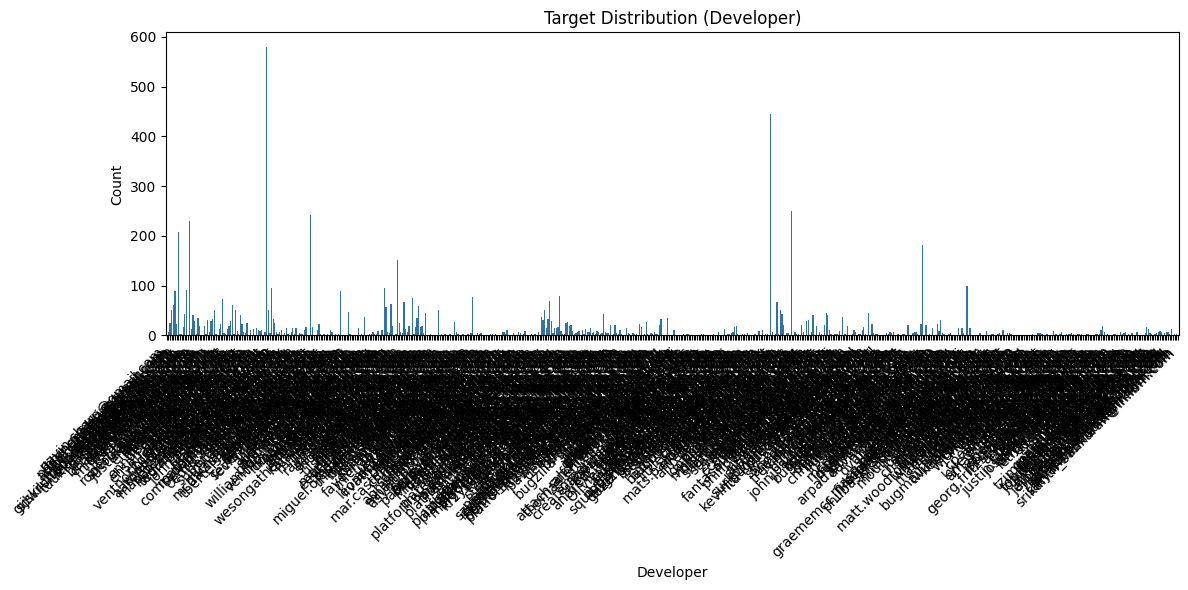

In [ ]:
# plot taregt disctirbution for developer

plt.figure(figsize=(12, 6))
sns.countplot(x='developer', data=df)
plt.title('Target Distribution (Developer)')
plt.xlabel('Developer')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [ ]:
# Group by developer and count the number of bugs
developer_bug_counts = df.groupby('developer')['developer'].count().reset_index(name='bug_count')

# Sort by bug count in descending order and select the top 30
top_30_developers = developer_bug_counts.sort_values('bug_count', ascending=False).head(30)

# Print the developer name and bug count
print(top_30_developers[['developer', 'bug_count']])

                    developer  bug_count
111          bzbarsky@mit.edu        580
87        brendan@mozilla.org        444
505         roc@ocallahan.org        250
433          mrbkap@gmail.com        243
379          mano@mozilla.com        230
451        nobody@mozilla.org        207
239               gal@uci.edu        182
162         dbaron@dbaron.org        151
240     gavin.sharp@gmail.com        105
270           hsivonen@iki.fi         99
468   peterv@propagandism.org         96
597        vladimir@pobox.com         95
173      dietrich@mozilla.com         92
100       bugs@bengoodger.com         90
12      Olli.Pettay@gmail.com         89
491       pwebster@ca.ibm.com         79
599        vporof@mozilla.com         77
495      raymond@appcoast.com         75
376         mak77@supereva.it         74
152  daniel_megert@ch.ibm.com         69
418     mihai.sucan@gmail.com         68
163        dbaron@mozilla.com         67
329           jst@mozilla.org         64
164         dcam

In [ ]:
# Create a new DataFrame containing only the top 30 developers
top_30_df = df[df['developer'].isin(top_30_developers['developer'])]

print(top_30_df.head())

    Bug Report ID                                        description  \
0          323798                  Keyword URL Needs to be localized   
5          324202  Don't Change the title of feed items to the ti...   
6          324948  Bookmark management should work when parent is...   
11         325042  Feedback survey prevents uninstaller from comp...   
12         325236  memory corruption probably caused by chrome al...   

                   developer  severity priority  
0      gavin.sharp@gmail.com    normal       P1  
5   annie.sullivan@gmail.com    normal       P2  
6        bugs@bengoodger.com    normal       P2  
11        nobody@mozilla.org    normal       P1  
12     gavin.sharp@gmail.com  critical       P1  


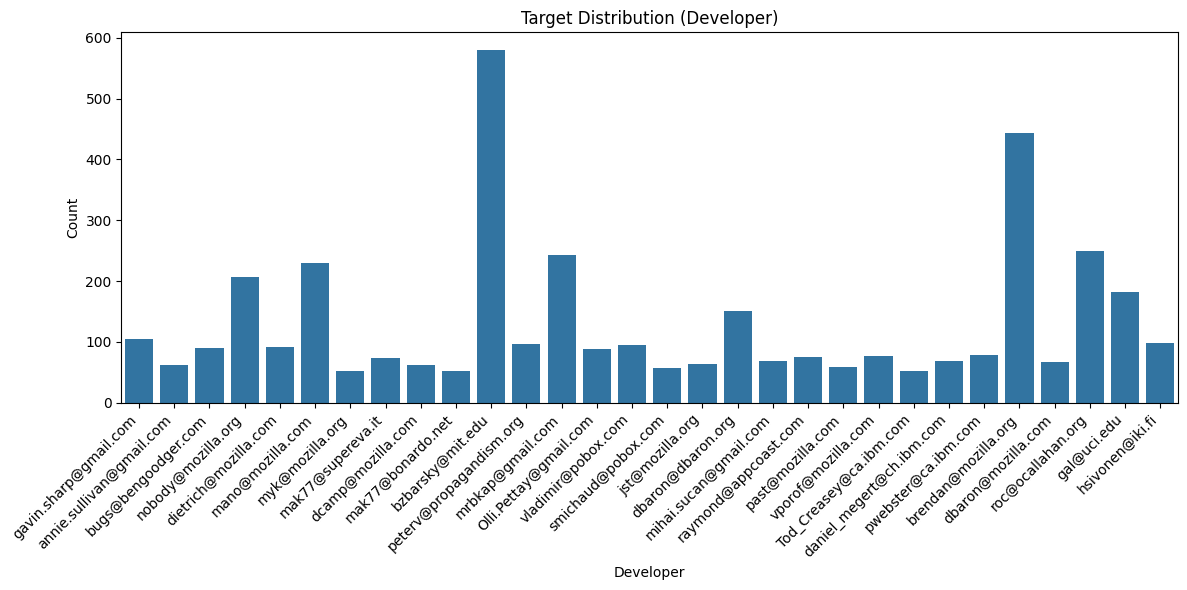

In [ ]:
# plot taregt disctirbution for developer

plt.figure(figsize=(12, 6))
sns.countplot(x='developer', data=top_30_df)
plt.title('Target Distribution (Developer)')
plt.xlabel('Developer')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

# Handle class imbalance

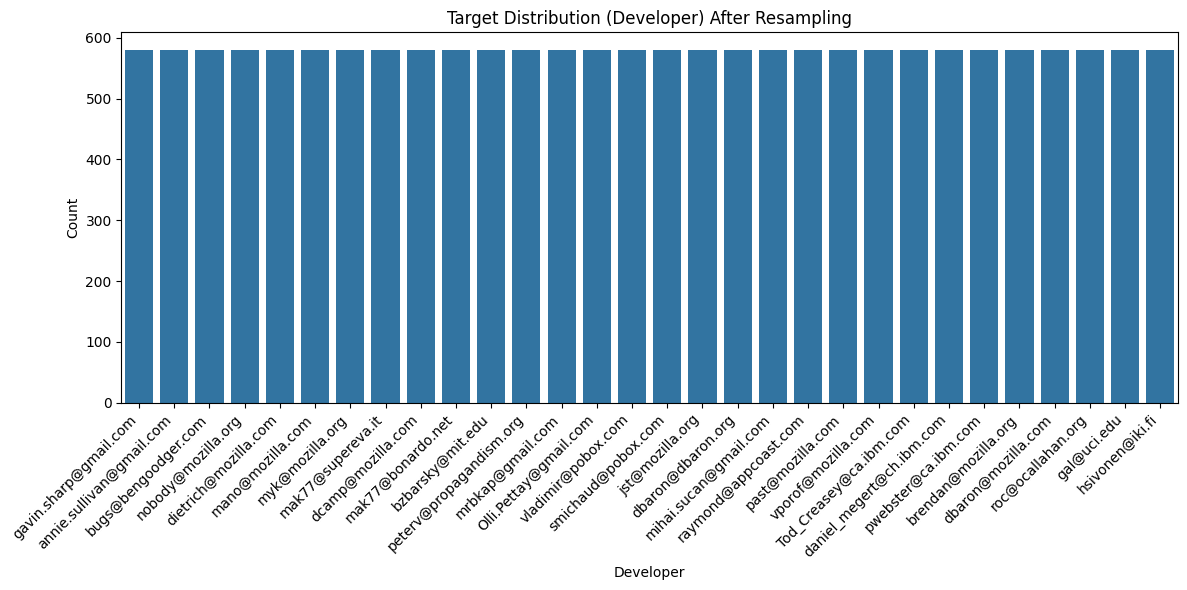

In [ ]:
# handle class imbalance
from imblearn.over_sampling import RandomOverSampler

sampler = RandomOverSampler(random_state=42)  # Or SMOTE, RandomUnderSampler, etc.

# Resample the data
X = top_30_df.drop('developer', axis=1)  # Features (excluding the target)
y = top_30_df['developer']  # Target variable
X_resampled, y_resampled = sampler.fit_resample(X, y)

# Convert the resampled data back to a DataFrame
top_30_df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
top_30_df_resampled['developer'] = y_resampled


# Verify the class distribution after resampling
plt.figure(figsize=(12, 6))
sns.countplot(x='developer', data=top_30_df_resampled)
plt.title('Target Distribution (Developer) After Resampling')
plt.xlabel('Developer')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
top_30_df_resampled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17400 entries, 0 to 17399
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Bug Report ID  17400 non-null  int64 
 1   description    17400 non-null  object
 2   severity       17400 non-null  object
 3   priority       17400 non-null  object
 4   developer      17400 non-null  object
dtypes: int64(1), object(4)
memory usage: 679.8+ KB


In [ ]:
print(top_30_df_resampled.head())

   Bug Report ID                                        description  severity  \
0         323798                  Keyword URL Needs to be localized    normal   
1         324202  Don't Change the title of feed items to the ti...    normal   
2         324948  Bookmark management should work when parent is...    normal   
3         325042  Feedback survey prevents uninstaller from comp...    normal   
4         325236  memory corruption probably caused by chrome al...  critical   

  priority                 developer  
0       P1     gavin.sharp@gmail.com  
1       P2  annie.sullivan@gmail.com  
2       P2       bugs@bengoodger.com  
3       P1        nobody@mozilla.org  
4       P1     gavin.sharp@gmail.com  


In [ ]:
# Map categorical features into integers
severity_mapping = {"blocker": 0, "critical": 1, "major": 2, "normal": 3, "minor": 4, "trivial": 5}
priority_mapping = {"P1": 0, "P2": 1, "P3": 2, "P4": 3, "P5": 4}

# Apply mappings
top_30_df_resampled['severity'] = top_30_df_resampled['severity'].map(severity_mapping)
top_30_df_resampled['priority'] = top_30_df_resampled['priority'].map(priority_mapping)


In [ ]:
top_30_df_resampled.head()

,Bug Report ID,description,severity,priority,developer
0,323798,Keyword URL Needs to be localized,3,0,gavin.sharp@gmail.com
1,324202,Don't Change the title of feed items to the ti...,3,1,annie.sullivan@gmail.com
2,324948,Bookmark management should work when parent is...,3,1,bugs@bengoodger.com
3,325042,Feedback survey prevents uninstaller from comp...,3,0,nobody@mozilla.org
4,325236,memory corruption probably caused by chrome al...,1,0,gavin.sharp@gmail.com


In [ ]:
# Preprocess data
bug_descriptions = top_30_df_resampled['description'].values
# severity = top_30_df_resampled['severity'].values
# priority = top_30_df_resampled['priority'].values
developer_ids = top_30_df_resampled['developer'].values

severity = top_30_df_resampled['severity'].values
priority = top_30_df_resampled['priority'].values

# Train/test split

In [ ]:
# Encode developer IDs
label_encoder = LabelEncoder()
encoded_developer_ids = label_encoder.fit_transform(developer_ids)

# Split data into training and testing sets
X_train_desc, X_test_desc, X_train_sev, X_test_sev, X_train_pri, X_test_pri, y_train, y_test = train_test_split(
    bug_descriptions, severity, priority, encoded_developer_ids, test_size=0.2, random_state=42
)

# BERT

In [ ]:
# Load BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenize bug descriptions
X_train_desc_tokens = tokenizer(X_train_desc.tolist(), padding='max_length', truncation=True, return_tensors='tf', max_length=128)
X_test_desc_tokens = tokenizer(X_test_desc.tolist(), padding='max_length', truncation=True, return_tensors='tf', max_length=128)

In [ ]:
# BERT model
bert_model = TFBertModel.from_pretrained('bert-base-uncased')

# Input layers
input_ids = Input(shape=(128,), dtype=tf.int32, name='input_ids')
attention_mask = Input(shape=(128,), dtype=tf.int32, name='attention_mask')
severity_input = Input(shape=(1,), dtype=tf.float32, name='severity_input')
priority_input = Input(shape=(1,), dtype=tf.float32, name='priority_input')

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

In [ ]:
from tensorflow.keras.layers import Layer

class BertLayer(Layer):
    def __init__(self, **kwargs):
        super(BertLayer, self).__init__(**kwargs)
        self.bert = TFBertModel.from_pretrained("bert-base-uncased")

    def call(self, inputs):
        input_ids, attention_mask = inputs
        return self.bert(input_ids=input_ids, attention_mask=attention_mask)[0]

    def get_config(self):
        config = super(BertLayer, self).get_config()
        return config

In [ ]:
# Use the custom BERT layer
bert_output = BertLayer()([input_ids, attention_mask])

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

# CNN & Bi-LSTM

In [ ]:
# CNN layer
cnn_layer = Conv1D(filters=32, kernel_size=3, activation='relu')(bert_output)
cnn_layer = GlobalMaxPooling1D()(cnn_layer)


# Bi-LSTM layer
lstm_layer = Bidirectional(LSTM(64, return_sequences=True))(bert_output)
lstm_layer = GlobalAveragePooling1D()(lstm_layer)


# Embedding Layers
severity_embedding = Embedding(input_dim=6, output_dim=4)(severity_input)
priority_embedding = Embedding(input_dim=5, output_dim=4)(priority_input)

# Flatten embeddings
severity_embedding = Flatten()(severity_embedding)
priority_embedding = Flatten()(priority_embedding)


# Concatenate all features
concat_layer = Concatenate()([cnn_layer, lstm_layer, severity_embedding, priority_embedding])


# Model

In [ ]:
# Dense layers
dense_layer = Dense(128, activation='relu')(concat_layer)
dense_layer = Dropout(0.5)(dense_layer)
output_layer = Dense(len(label_encoder.classes_), activation='softmax')(dense_layer)

# Compile the model
model = Model(inputs=[input_ids, attention_mask, severity_input, priority_input], outputs=output_layer)
model.compile(optimizer=Adam(learning_rate=3e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_ids (InputLayer)    │ (None, 128)            │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention_mask            │ (None, 128)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bert_layer_1 (BertLayer)  │ (None, 128, 768)       │              0 │ input_ids[0][0],       │
│                           │                        │                │ attention_mask[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ severity_input            │ (None, 1)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ priority_input            │ (None, 1)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_2 (Conv1D)         │ (None, 126, 32)        │         73,760 │ bert_layer_1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_2           │ (None, 128, 128)       │        426,496 │ bert_layer_1[0][0]     │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_4 (Embedding)   │ (None, 1, 4)           │             24 │ severity_input[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_5 (Embedding)   │ (None, 1, 4)           │             20 │ priority_input[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_max_pooling1d_2    │ (None, 32)             │              0 │ conv1d_2[0][0]         │
│ (GlobalMaxPooling1D)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling1d… │ (None, 128)            │              0 │ bidirectional_2[0][0]  │
│ (GlobalAveragePooling1D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_4 (Flatten)       │ (None, 4)              │              0 │ embedding_4[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_5 (Flatten)       │ (None, 4)              │              0 │ embedding_5[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_2             │ (None, 168)            │              0 │ global_max_pooling1d_… │
│ (Concatenate)             │                        │                │ global_average_poolin… │
│                           │                        │                │ flatten_4[0][0],       │
│                           │                        │                │ flatten_5[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)      

 Total params: 525,802 (2.01 MB)

 Trainable params: 525,802 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

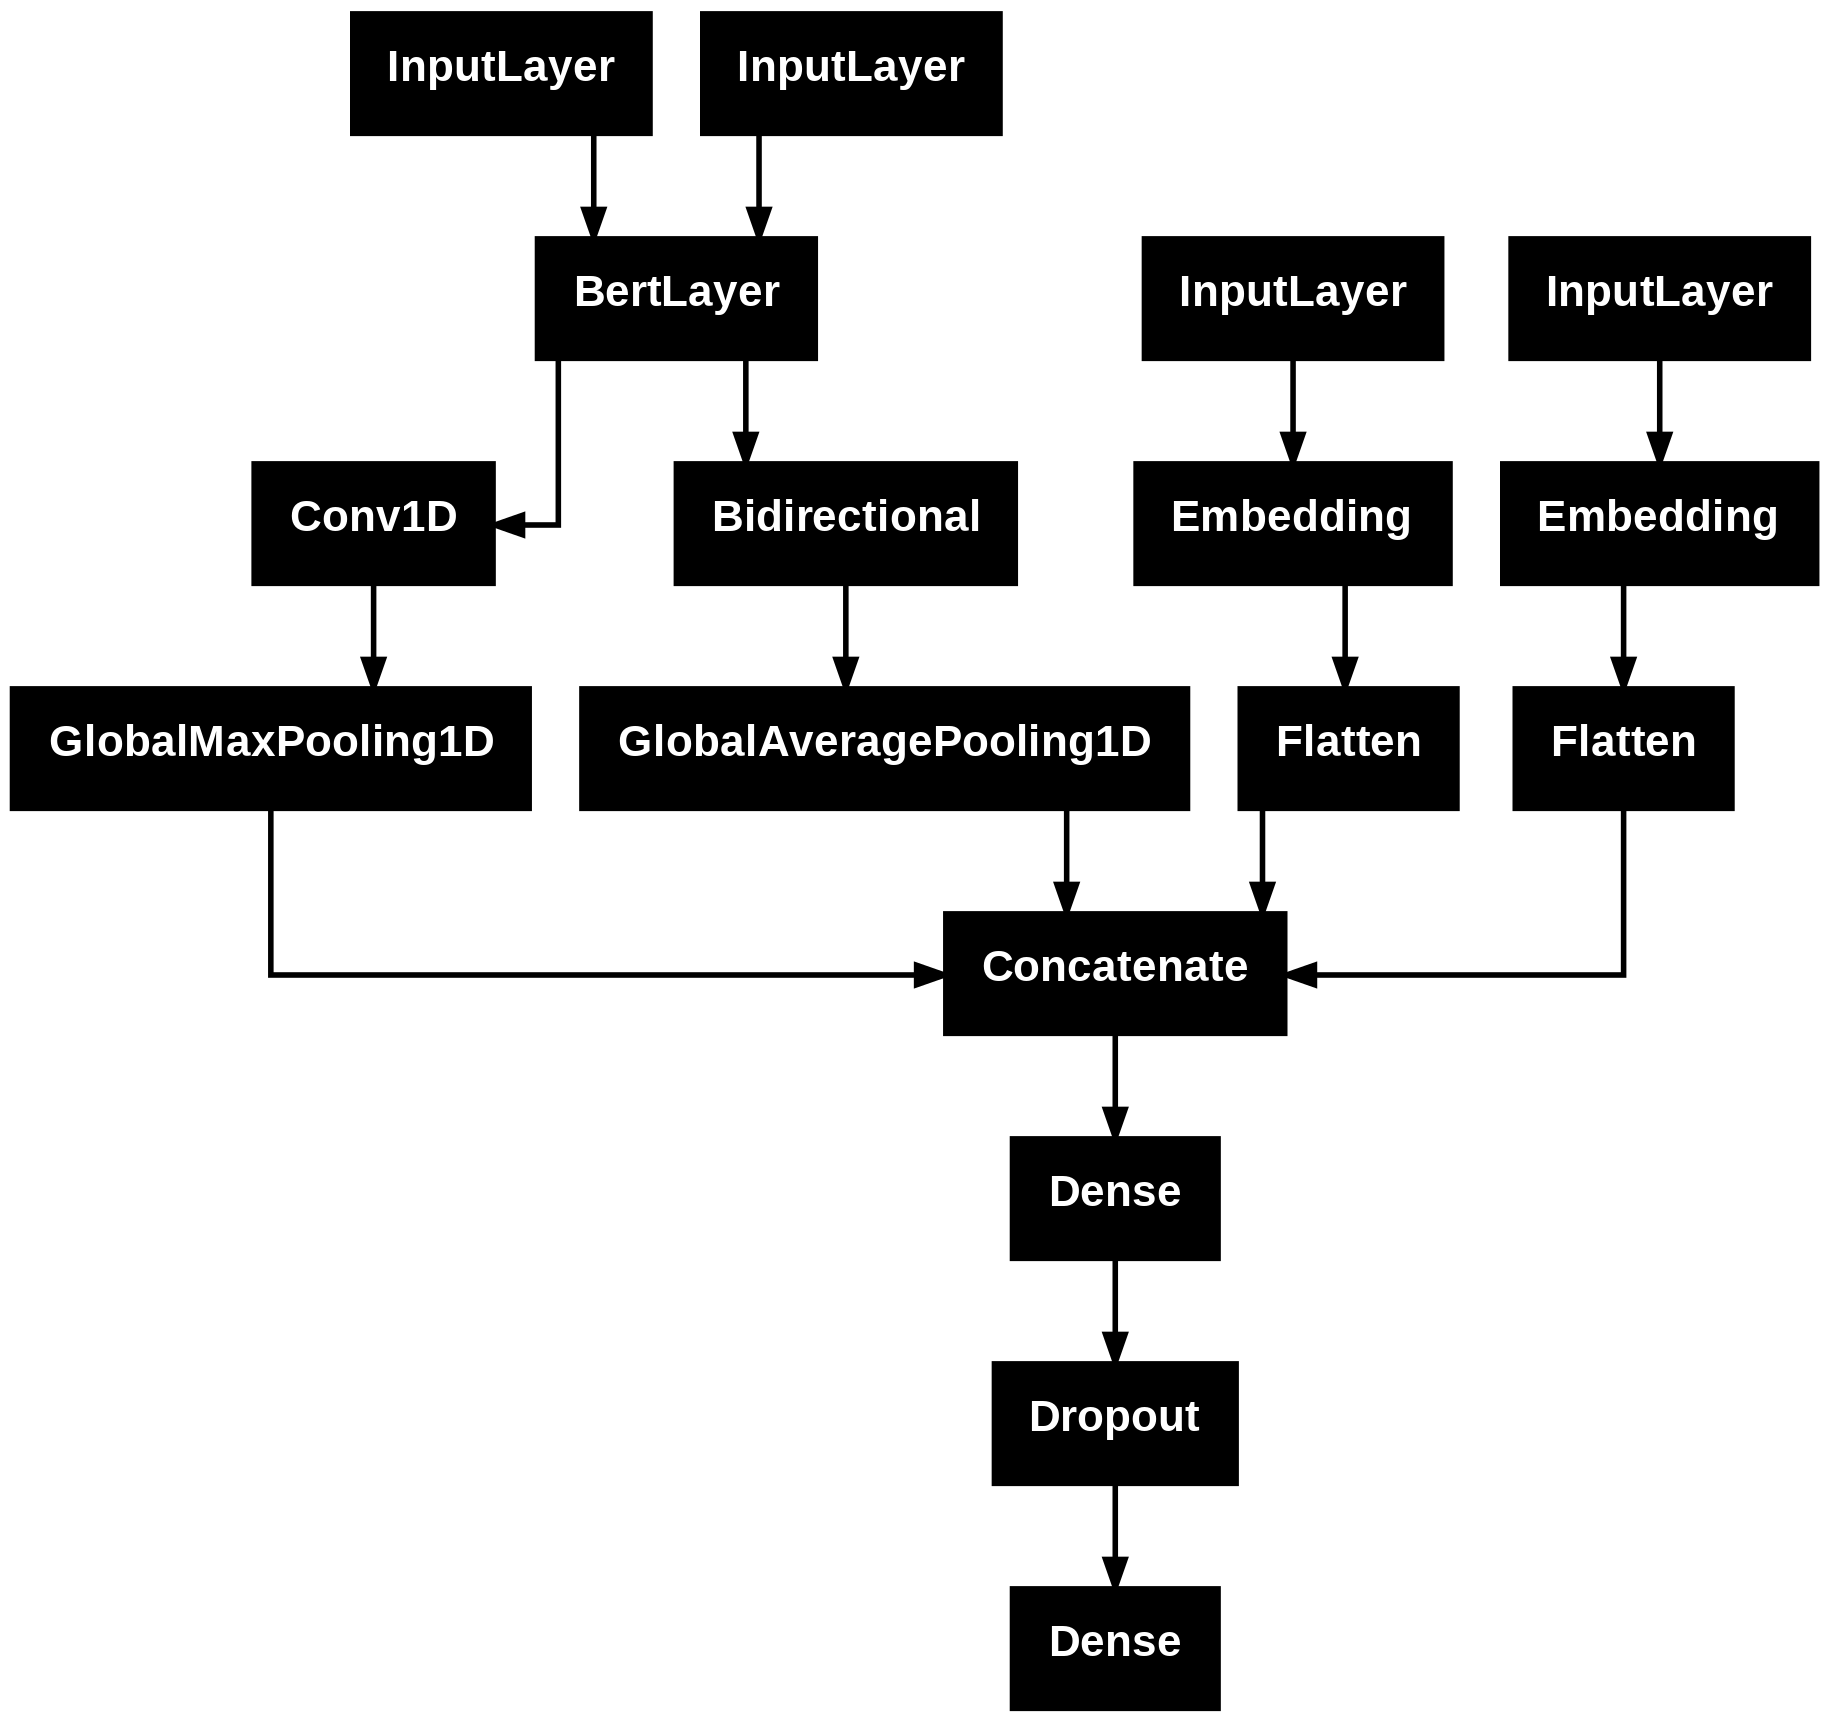

In [ ]:
tf.keras.utils.plot_model(model)

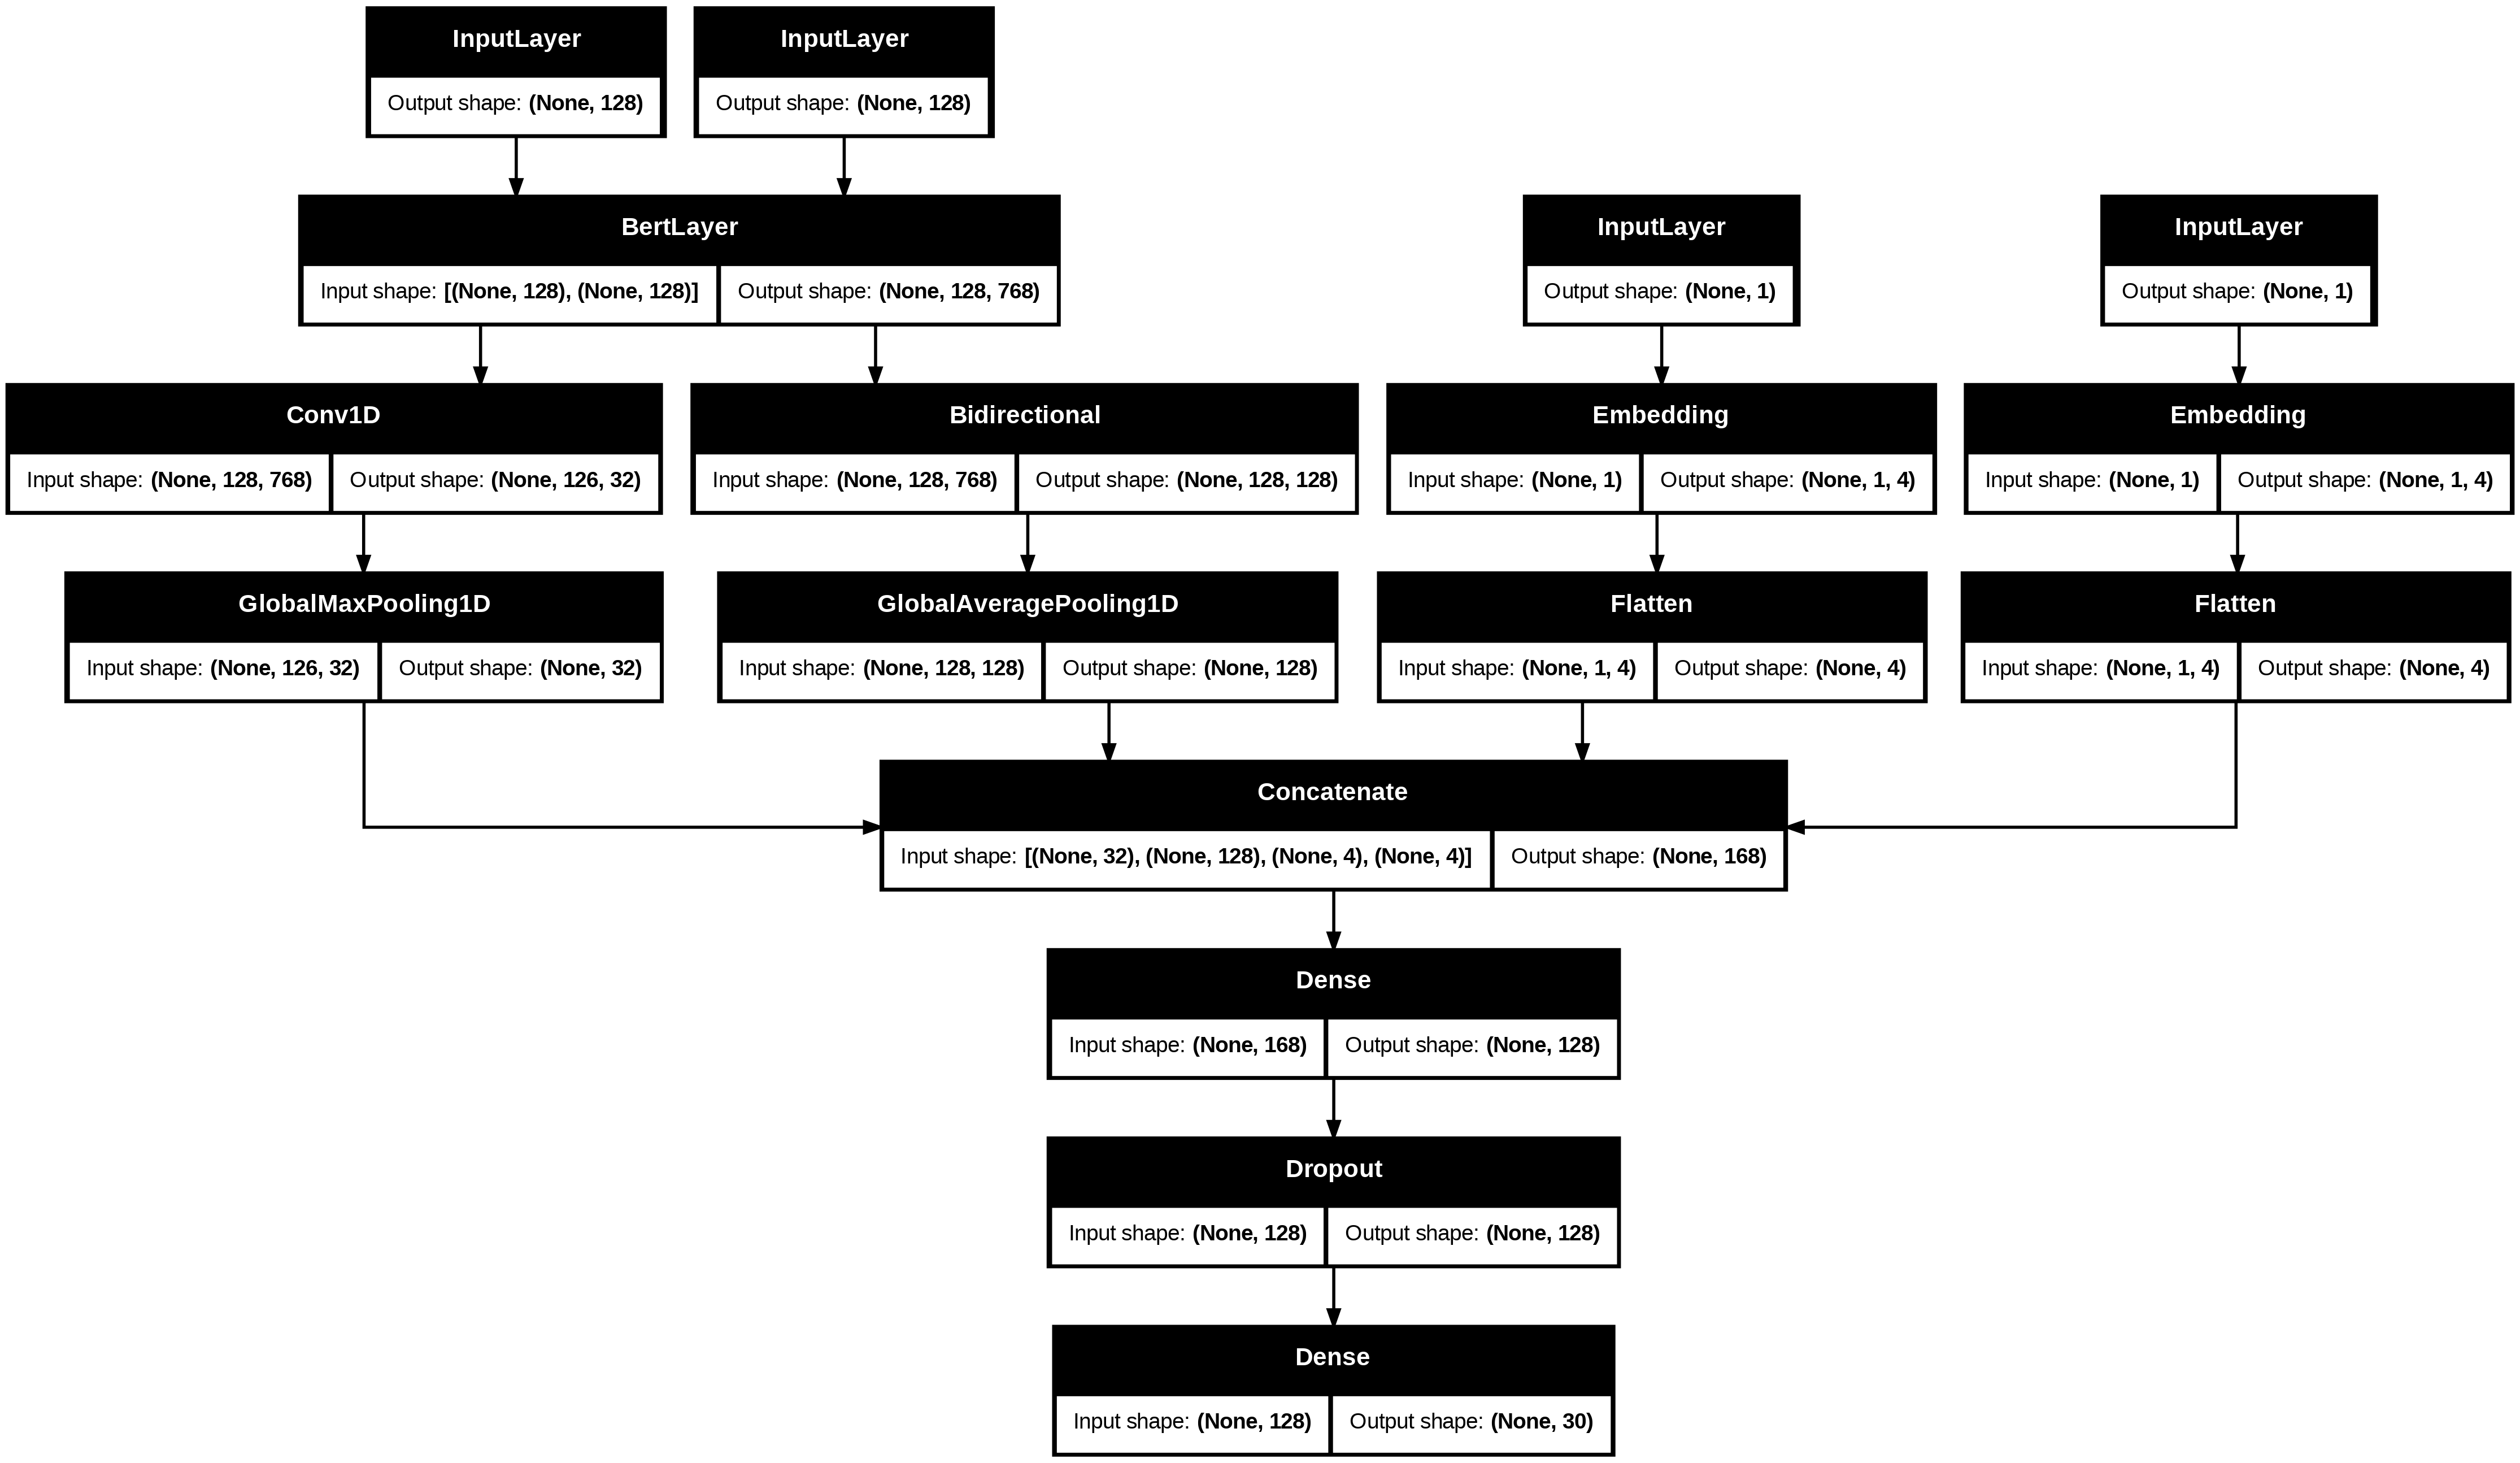

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True)

# Train model

In [ ]:
# Prepare inputs for training
train_inputs = {
    'input_ids': X_train_desc_tokens['input_ids'],
    'attention_mask': X_train_desc_tokens['attention_mask'],
    'severity_input': np.array(X_train_sev, dtype=np.float32).reshape(-1, 1),
    'priority_input': np.array(X_train_pri, dtype=np.float32).reshape(-1, 1)
}


In [ ]:
print("Input IDs shape:", X_train_desc_tokens["input_ids"].shape)
print("Attention mask shape:", X_train_desc_tokens["attention_mask"].shape)
print("Severity shape:", np.array(X_train_sev).shape)
print("Priority shape:", np.array(X_train_pri).shape)
print("Labels shape:", y_train.shape)


Input IDs shape: (13920, 128)
Attention mask shape: (13920, 128)
Severity shape: (13920,)
Priority shape: (13920,)
Labels shape: (13920,)


In [ ]:
# Train the model
history = model.fit(train_inputs, y_train, epochs=5, batch_size=16, validation_split=0.2)

Epoch 1/5
696/696 ━━━━━━━━━━━━━━━━━━━━ 129s 172ms/step - accuracy: 0.1270 - loss: 3.1413 - val_accuracy: 0.4529 - val_loss: 2.0538
Epoch 2/5
696/696 ━━━━━━━━━━━━━━━━━━━━ 139s 200ms/step - accuracy: 0.4143 - loss: 2.0381 - val_accuracy: 0.6566 - val_loss: 1.4085
Epoch 3/5
696/696 ━━━━━━━━━━━━━━━━━━━━ 142s 200ms/step - accuracy: 0.5999 - loss: 1.4143 - val_accuracy: 0.7805 - val_loss: 0.9466
Epoch 4/5
696/696 ━━━━━━━━━━━━━━━━━━━━ 142s 200ms/step - accuracy: 0.7184 - loss: 0.9992 - val_accuracy: 0.8305 - val_loss: 0.6940
Epoch 5/5
696/696 ━━━━━━━━━━━━━━━━━━━━ 142s 200ms/step - accuracy: 0.8012 - loss: 0.7137 - val_accuracy: 0.8664 - val_loss: 0.5392


In [ ]:
# Prepare inputs for testing
test_inputs = {
    'input_ids': X_test_desc_tokens['input_ids'],
    'attention_mask': X_test_desc_tokens['attention_mask'],
    'severity_input': np.array(X_test_sev, dtype=np.float32).reshape(-1, 1),
    'priority_input': np.array(X_test_pri, dtype=np.float32).reshape(-1, 1)
}

# Evaluate the model
loss, accuracy = model.evaluate(test_inputs, y_test)
print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')

109/109 ━━━━━━━━━━━━━━━━━━━━ 34s 270ms/step - accuracy: 0.8631 - loss: 0.5329
Test Loss: 0.525579035282135
Test Accuracy: 0.865517258644104


# Traning/validation loss

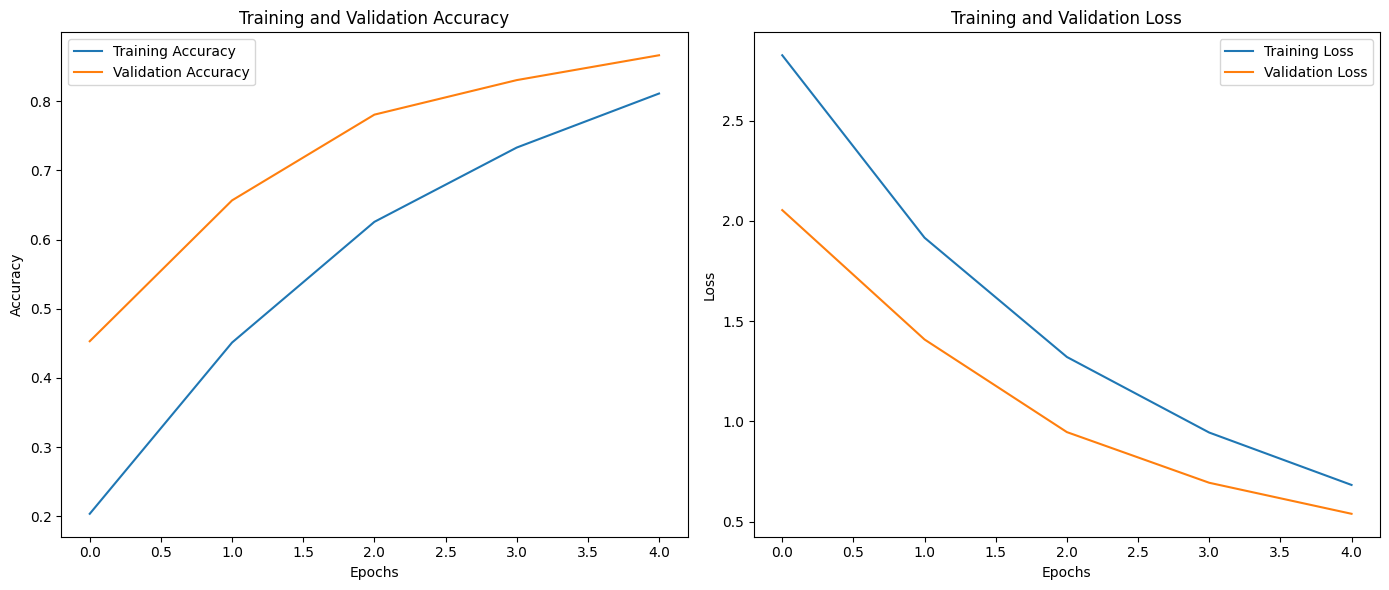

In [ ]:
# Create two subplots for training and validation accuracy and loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot training and validation accuracy on the first subplot
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.set_title('Training and Validation Accuracy')

# Plot training and validation loss on the second subplot
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.set_title('Training and Validation Loss')

# Display the plots
plt.tight_layout()
plt.show()

# Confusion matrix

109/109 ━━━━━━━━━━━━━━━━━━━━ 33s 284ms/step


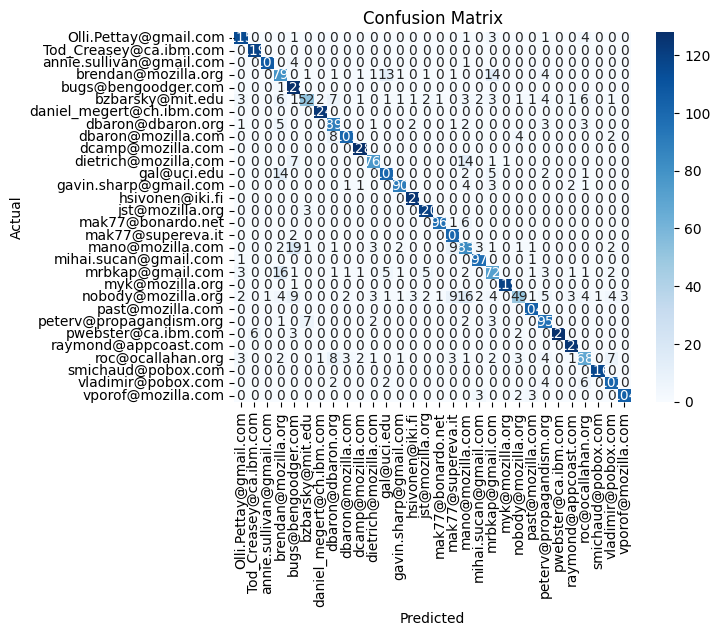

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on the test set
y_pred = model.predict(test_inputs)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report

In [ ]:
from sklearn.metrics import classification_report

# Classification report
print(classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_))

                          precision    recall  f1-score   support

   Olli.Pettay@gmail.com       0.90      0.92      0.91       125
  Tod_Creasey@ca.ibm.com       0.95      1.00      0.98       119
annie.sullivan@gmail.com       0.99      0.96      0.97       112
     brendan@mozilla.org       0.61      0.68      0.64       117
     bugs@bengoodger.com       0.73      0.99      0.84       129
        bzbarsky@mit.edu       0.81      0.52      0.63       100
daniel_megert@ch.ibm.com       0.98      1.00      0.99       124
       dbaron@dbaron.org       0.76      0.83      0.79       107
      dbaron@mozilla.com       0.94      0.88      0.91       115
       dcamp@mozilla.com       0.96      1.00      0.98       128
    dietrich@mozilla.com       0.87      0.77      0.82        99
             gal@uci.edu       0.82      0.81      0.81       125
   gavin.sharp@gmail.com       0.93      0.88      0.90       102
         hsivonen@iki.fi       0.95      1.00      0.98       125
         

# Predictions

In [ ]:
# Display some predictions
for i in range(6):
    print(f"Bug Description: {X_test_desc[i]}")
    print(f"Actual Developer: {label_encoder.inverse_transform([y_test[i]])[0]}")
    print(f"Predicted Developer: {label_encoder.inverse_transform([y_pred_classes[i]])[0]}")
    print()

Bug Description: Places crashes after creating new separator
Actual Developer: bugs@bengoodger.com
Predicted Developer: bugs@bengoodger.com

Bug Description: [PPC] Bookmark root folder gets deleted after some minutes or by user action (opening/closing tabs, reload live bookmark)
Actual Developer: dietrich@mozilla.com
Predicted Developer: bugs@bengoodger.com

Bug Description: [WorkbenchParts] Console view does not open when first running
Actual Developer: pwebster@ca.ibm.com
Predicted Developer: pwebster@ca.ibm.com

Bug Description: Middle clicking an item in the places view should open it in a new tab
Actual Developer: bugs@bengoodger.com
Predicted Developer: bugs@bengoodger.com

Bug Description: Importing a large bookmarks JSON backup makes Firefox crash (out of memory)
Actual Developer: mak77@bonardo.net
Predicted Developer: mak77@bonardo.net

Bug Description: Unable to access nsIDOMFile using [] operator
Actual Developer: dcamp@mozilla.com
Predicted Developer: dcamp@mozilla.com



In [ ]:
# Predict the most suitable developer for a new bug
new_bug_description = "Console view does not open first"
new_severity = 2.0
new_priority = 1.0

# Tokenize the new bug description
new_bug_tokens = tokenizer([new_bug_description], padding='max_length', truncation=True, return_tensors='tf', max_length=128)

# Prepare inputs for prediction
prediction_inputs = {
    'input_ids': new_bug_tokens['input_ids'],
    'attention_mask': new_bug_tokens['attention_mask'],
    'severity_input': np.array([new_severity], dtype=np.float32).reshape(-1, 1),
    'priority_input': np.array([new_priority], dtype=np.float32).reshape(-1, 1)
}

# Make prediction
predicted_probabilities = model.predict(prediction_inputs)
predicted_developer_id = np.argmax(predicted_probabilities, axis=1)

# Decode the predicted developer ID
predicted_developer = label_encoder.inverse_transform(predicted_developer_id)
print(f'Predicted Developer: {predicted_developer[0]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Predicted Developer: mihai.sucan@gmail.com


# Save and load model

In [ ]:
# model.save('/models/bug_triage_model_1.h5')
model.save('/content/drive/MyDrive/models/bug_triage_model_2.h5')

In [ ]:
# Save the tokenizer
tokenizer.save_pretrained('/content/drive/MyDrive/models/tokenizer_2')

('/content/drive/MyDrive/models/tokenizer_2/tokenizer_config.json',
 '/content/drive/MyDrive/models/tokenizer_2/special_tokens_map.json',
 '/content/drive/MyDrive/models/tokenizer_2/vocab.txt',
 '/content/drive/MyDrive/models/tokenizer_2/added_tokens.json')

In [ ]:
# Save the label encoder
import joblib
joblib.dump(label_encoder, '/content/drive/MyDrive/models/label_encoder_2.pkl')

['/content/drive/MyDrive/models/label_encoder_2.pkl']